In [164]:
import numpy as np
import matplotlib.pyplot as plt

def make_arrow(plt,start_point,end_point):
    plt.annotate(
            '', 
            xy=end_point,  # arrow tip
            xytext=start_point,              # arrow tail
            arrowprops=dict(
                arrowstyle='->',    # clean arrow
                color='red',
                lw=2,               # thickness
                alpha=0.8
            )
        )

## Descente de gradient f(x) = x²

In [165]:
def f(x):
    ''' On définit une fonction quadratique'''
    return x**2 ###

def df(x):
    ''' On définit la dérivée de la fonction '''
    return 2*x ###

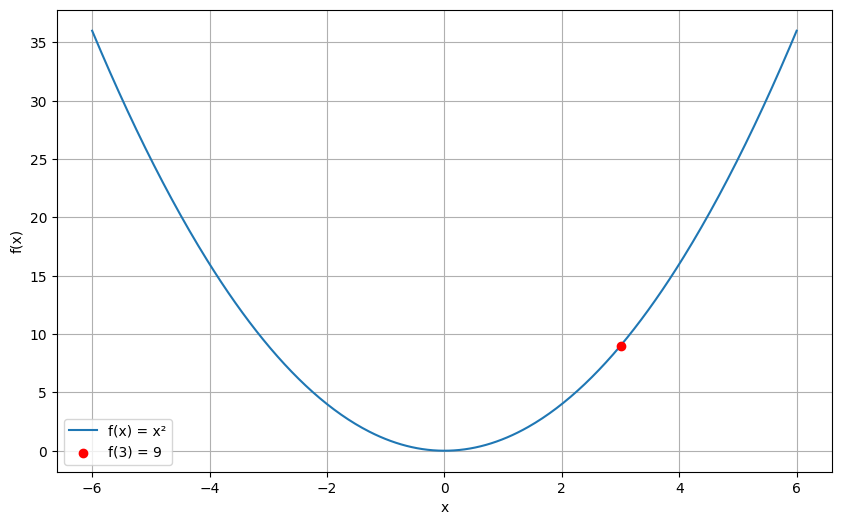

In [166]:
x = 3  ###

# Plotting f
x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, label='f(x) = x²')
plt.scatter(x, f(x), color='red', zorder=5, label=f'f({x}) = {f(x)}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

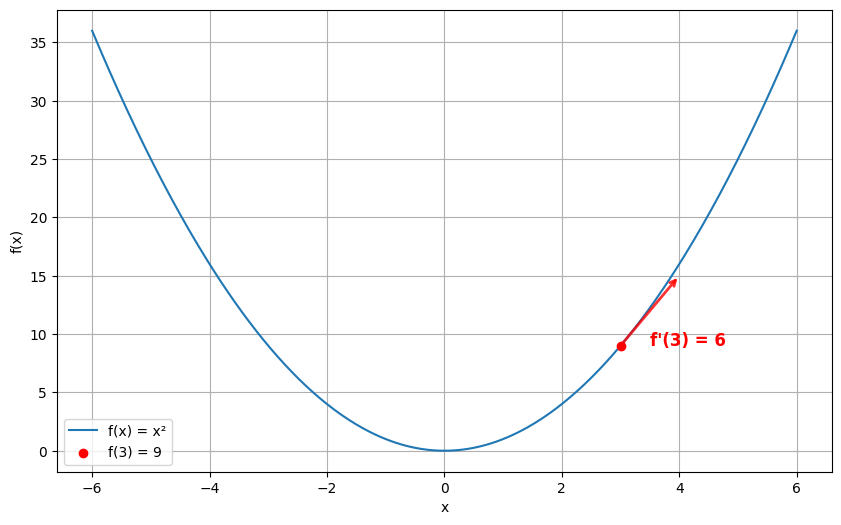

In [167]:

x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, label='f(x) = x²')
plt.scatter(x, f(x), color='red', zorder=5, label=f'f({x}) = {f(x)}')
make_arrow(plt,(x,f(x)),(x+1,f(x)+df(x)))


plt.text(
    x + 0.5,              # slightly offset to avoid overlapping the arrow tip
    f(x) ,
    f"f'({x}) = {df(x)}",
    color='red',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

Foretale descente de gradient :

$$ \vec{\theta} \leftarrow  \vec{\theta}  - \eta . \vec{\nabla}_{\vec{\theta}}\mathcal{L}(\vec{\theta},X,Y) $$

Ou écrit différement, en 1D:

$$ x(t+1) =  x(t) - \eta . f'(x) $$


In [ ]:
def descente_de_gradient(df,eta,x):
    return x-eta*df(x) ##

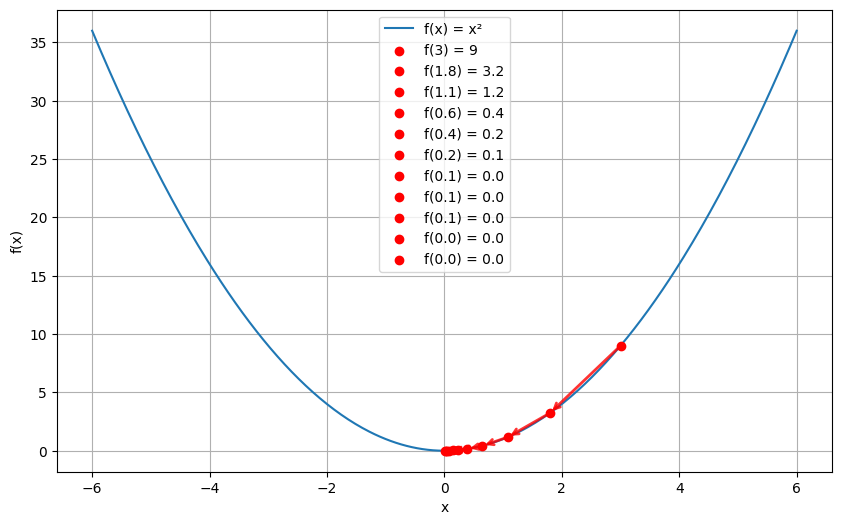

In [ ]:
eta = 0.2 ##
x = 3 ##
x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, label='f(x) = x²')
plt.scatter(x, f(x), color='red', zorder=5, label=f'f({x}) = {f(x)}')


for step in range(10):
    next_x = descente_de_gradient(df,eta,x)
    make_arrow(plt,(x,f(x)),(next_x,f(next_x)))
    plt.scatter(next_x, f(next_x), color='red', zorder=5, label=f'f({next_x:.1f}) = {f(next_x):.1f}')
    x = next_x


plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Descente de gradient f(x) = x²

In [170]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return 2*x**2  - x + y**2 - 3

def grad_f(x, y):
    return np.array([4*x-1, 2*y]) ##


In [ ]:
def descente_de_gradient(eta, x0, y0, nombre_iteration):
    ''' On calcule nombre_iteration de la descente de gradient '''
    xs, ys = [x0], [y0]
    x, y = x0, y0

    for _ in range(nombre_iteration):
        gx, gy = grad_f(x, y)  ##
        x -= eta * gx ##
        y -= eta * gy ##
        xs.append(x) ##
        ys.append(y) ##

    return np.array(xs), np.array(ys)

In [ ]:
eta = 0.05
x0, y0 = -2.5, 2.0
steps = 15

xs, ys = descente_de_gradient(eta, x0, y0, steps)
zs = f(xs, ys)

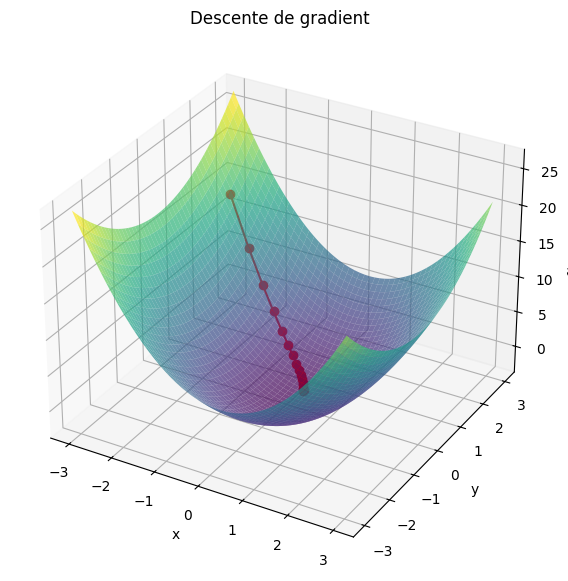

In [173]:
# Surface grid
grid = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(grid, grid)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, linewidth=0)

# Gradient descent path
ax.plot(xs, ys, zs, color='red', marker='o')

ax.set_title("Descente de gradient")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")

plt.show()


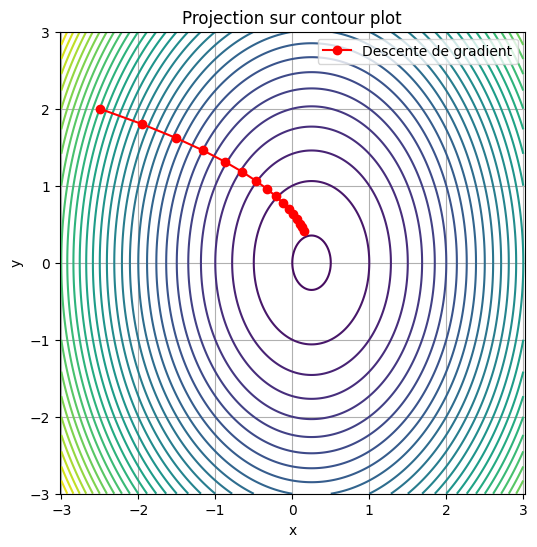

In [174]:
plt.figure(figsize=(6, 6))
plt.contour(X, Y, Z, levels=30)
plt.plot(xs, ys, 'ro-', label="Descente de gradient")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Projection sur contour plot")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()
